# 05.21 - Regression with Trees & Boosting

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Decision trees and gradient boosting also work for regression. They handle non-linear relationships without preprocessing.

## 2. Why Does This Matter?

Tree-based regression is the most powerful traditional ML for tabular data.

## 3. Prerequisites

- 05.05: Decision trees
- 05.07: Gradient boosting

## 4. Learning Objectives

- Apply decision tree regression
- Compare with linear regression
- Use gradient boosting for regression

## 5. Mental Model

Regression trees split to minimize MSE within each region.
Prediction: average of training samples in each leaf.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Decision Tree Regression

In [2]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target * 100000

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

print("Decision Tree Regressor:")
print("  RMSE: " + str(int(np.sqrt(mean_squared_error(y_test, y_pred_dt)))))
print("  MAE:  " + str(int(mean_absolute_error(y_test, y_pred_dt))))
print("  R2:   " + str(round(r2_score(y_test, y_pred_dt), 4)))

Decision Tree Regressor:
  RMSE: 72423
  MAE:  52225
  R2:   0.5997


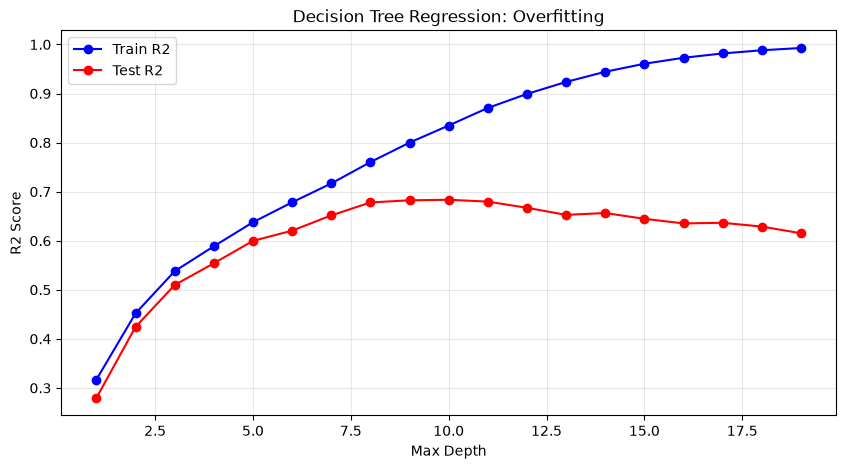

In [3]:
depths = range(1, 20)
train_r2 = []
test_r2 = []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, dt.predict(X_train)))
    test_r2.append(r2_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(list(depths), train_r2, "b-o", label="Train R2")
plt.plot(list(depths), test_r2, "r-o", label="Test R2")
plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.title("Decision Tree Regression: Overfitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("dt_regression_overfit.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Random Forest & Gradient Boosting Regression

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (d=5)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAE": round(mean_absolute_error(y_test, y_pred)),
        "R2": round(r2_score(y_test, y_pred), 4)
    })

print(pd.DataFrame(results).to_string(index=False))

              Model  RMSE   MAE     R2
  Linear Regression 74558 53320 0.5758
Decision Tree (d=5) 72423 52226 0.5997
      Random Forest 50715 32799 0.8037
  Gradient Boosting 54222 37164 0.7756


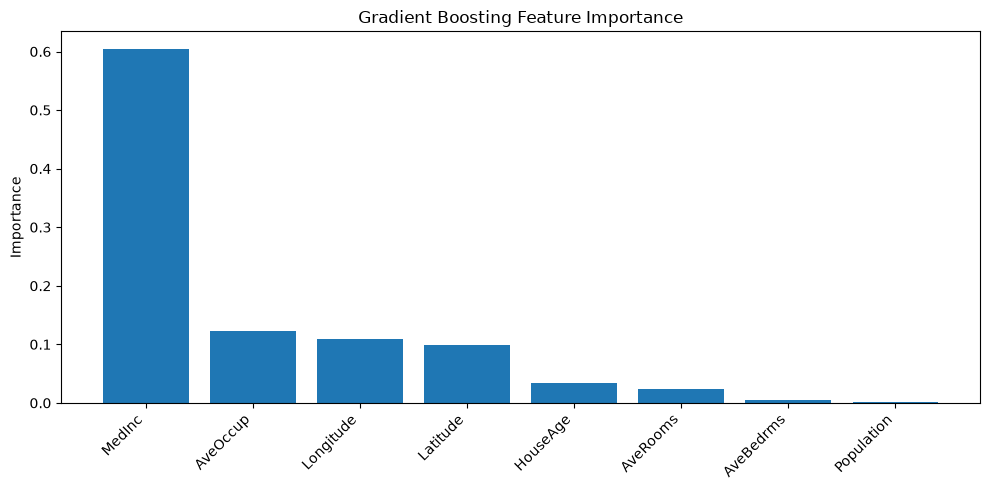

In [5]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

importances = gb.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), [X.columns[i] for i in idx], rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.savefig("gb_regression_importance.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Common Mistakes

1. Using accuracy for regression
2. Not tuning max_depth
3. Ignoring feature scaling for linear models

## 9. Coding Exercises

### Exercise 1: XGBoost Regressor
Try XGBoost for regression.

### Exercise 2: Learning Curves
Plot learning curves for RF and GB.

In [6]:
# EXERCISE 1: XGBoost Regressor
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
    xgb.fit(X_train, y_train)
    print("XGBoost R2: " + str(round(r2_score(y_test, xgb.predict(X_test)), 4)))
except ImportError:
    print("XGBoost not installed.")

XGBoost R2: 0.8139


In [7]:
# EXERCISE 2: Learning Curves
from sklearn.model_selection import learning_curve
print("Exercise: Plot learning curves using learning_curve().")

Exercise: Plot learning curves using learning_curve().


## 10. Closed-Book Recall

1. How do regression trees split?
2. What is the difference between RF and GB for regression?
3. When do tree models need feature scaling?

## 11. Teach-Back Questions

Explain regression trees vs linear regression. How gradient boosting reduces bias.

## 12. Summary

Tree-based regression handles non-linear relationships. RF reduces variance, GB reduces bias. Most powerful for tabular data.

## 13. Further Experiment

1. Tune XGBoost with Optuna.
2. Compare with neural networks.
3. Try on a time-series dataset.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```